In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else NOTEBOOK_DIR
)

for path in (PROJECT_DIR, PROJECT_DIR / "src"):  # src/: modules import each other as crypto_impact.*
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from src.crypto_impact.binning import (
    bin_impact_curve_with_uncertainty,
)
from src.crypto_impact.impact import (
    add_trailing_impact_normalisation,
)
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars_multi,
    build_time_bars,
)
from src.crypto_impact.regime_analysis import (
    build_analysis_table,
)
from src.crypto_impact.regression import (
    compare_impact_models,
)

# Corrected trade events (one event per same-sign run of fills at a millisecond
# timestamp, priced at the run's last fill; scripts/export_paper_events.py), on the
# shared data drive. The legacy files in data/raw/BTCUSDT_monthly (first-fill price
# and sign per timestamp, 2025-01..2026-05) are no longer used.
SHARED_ACADEMIC = PROJECT_DIR.parent / "shared-data" / "features" / "academic" / "symbol=BTCUSDT"
DATA_DIR = Path(os.environ.get("CRYPTO_IMPACT_DATA_DIR", SHARED_ACADEMIC / "paper_events_v2"))
SAMPLE_START = os.environ.get("CRYPTO_IMPACT_SAMPLE_START", "2021-01")
SAMPLE_END = os.environ.get("CRYPTO_IMPACT_SAMPLE_END", "2026-08")
assert SAMPLE_END <= "2026-08", "Data from 2026-09 onward is reserved for the alpha-search P-006 test."

# Redo outputs sit beside the other full-sample notebook reruns, so the paper's
# original reports/figures and reports/tables are not overwritten.
FIGURE_DIR = Path(os.environ.get("CRYPTO_IMPACT_FIGURE_DIR", PROJECT_DIR / "reports" / "redo" / "paper" / "figures"))
TABLE_DIR = Path(os.environ.get("CRYPTO_IMPACT_TABLE_DIR", PROJECT_DIR / "reports" / "redo" / "paper" / "tables"))

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FILES = sorted(
    path for path in DATA_DIR.glob("BTCUSDT-trades-*.parquet")
    if SAMPLE_START <= path.stem.removeprefix("BTCUSDT-trades-") <= SAMPLE_END
)
print(f"Files selected: {len(FILES)} ({FILES[0].name} to {FILES[-1].name})")

EVENT_COUNTS = [
    100,
    250,
    500,
    1_000,
    2_000,
    4_000,
    8_000,
    16_000,
]

N_BINS = 60  # equal-count bins for every event-bar and time-bar fit
# Bar sizes reported in Table tab:event-bar-robustness; also the sizes over which the
# common normalised-imbalance support is defined.
TABLE_EVENT_COUNTS = [250, 500, 1_000, 2_000, 4_000, 8_000, 16_000]
BIN_SENSITIVITY_EVENT_SIZES = [4_000, 16_000]
MIN_OBS_PER_BIN = 20
BASE_WINDOW = "2min"
BASE_BARS_PER_DAY = int(pd.Timedelta("1D") / pd.Timedelta(BASE_WINDOW))
# The trailing 24 h benchmark needs 90% of a day's benchmark bars: this excludes the
# sample's first day and any trailing day missing more than ~2.4 h, but keeps days
# containing short exchange pauses (a strict full-day rule would drop a whole day
# after every pause).
MIN_BENCHMARK_BARS = int(0.9 * BASE_BARS_PER_DAY)

Files selected: 68 (BTCUSDT-trades-2021-01.parquet to BTCUSDT-trades-2026-08.parquet)


In [2]:
# One read of each monthly file builds the benchmark bars (scripts read the data once).
base_bars = build_time_bars(FILES, [BASE_WINDOW])[BASE_WINDOW]

base_bars["duration_seconds"] = pd.Timedelta(BASE_WINDOW).total_seconds()
base_bars["current_return_bps"] = (
    base_bars["log_return_bps"]
)
base_bars["end_time"] = (
    base_bars.index
    + pd.Timedelta(BASE_WINDOW)
)

base_benchmark = add_trailing_impact_normalisation(
    base_bars,
    window="1D",
    min_periods=MIN_BENCHMARK_BARS,
    timestamp_col=None,
)

benchmark_columns = [
    "trailing_market_volume",
    "trailing_realised_volatility_bps",
]

base_benchmark = (
    base_benchmark[benchmark_columns]
    .dropna()
    .sort_index()
)

base_benchmark.head()

,trailing_market_volume,trailing_realised_volatility_bps
timestamp,,
2021-01-01 21:36:00+00:00,201750.748,318.859023
2021-01-01 21:38:00+00:00,202033.576,319.040321
2021-01-01 21:40:00+00:00,202231.533,319.378804
2021-01-01 21:42:00+00:00,202319.178,319.396799
2021-01-01 21:44:00+00:00,202450.710,319.437047


In [3]:
def attach_common_benchmark(
    event_bars: pd.DataFrame,
    benchmark: pd.DataFrame,
) -> pd.DataFrame:
    analysis = build_analysis_table(
        event_bars.drop(
            columns=["high_low_range_bps"],
            errors="ignore",
        ),
        horizons=(),
    )

    left = (
        analysis
        .sort_index()
        .rename_axis("start_time")
        .reset_index()
    )

    right = (
        benchmark
        .sort_index()
        .rename_axis("benchmark_time")
        .reset_index()
    )

    left = left.sort_values("start_time")
    right = right.sort_values("benchmark_time")
    
    merged = pd.merge_asof(
        left,
        right,
        left_on="start_time",
        right_on="benchmark_time",
        direction="backward",
    )

    merged["signed_current_impact_bps"] = (
        np.sign(merged["signed_imbalance"])
        * merged["current_return_bps"]
    )

    merged["normalised_imbalance"] = (
        merged["signed_imbalance"].abs()
        / merged["trailing_market_volume"]
    )

    merged["normalised_signed_impact"] = (
        merged["signed_current_impact_bps"]
        / merged["trailing_realised_volatility_bps"]
    )

    merged.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True,
    )

    return merged.set_index("start_time")

In [4]:
analyses_by_size = {}

# All bar sizes from a single read of each monthly file.
bars_by_size = build_fixed_event_bars_multi(FILES, EVENT_COUNTS)

for events_per_bar in EVENT_COUNTS:
    bars_n = bars_by_size[events_per_bar]

    analysis_n = attach_common_benchmark(
        bars_n,
        base_benchmark,
    )

    analyses_by_size[events_per_bar] = analysis_n

pooled_x_scale = float(
    analyses_by_size[4_000][
        "normalised_imbalance"
    ]
    .dropna()
    .median()
)

pooled_x_scale

0.00041826583576298564

In [5]:
# Zero-range diagnostic on the last bar size built in the loop above (16,000 events).
zero_range = bars_n.loc[
    bars_n["high_low_range_bps"] <= 0,
    [
        "end_time",
        "trade_count",
        "start_price",
        "end_price",
        "high_price",
        "low_price",
        "high_low_range_bps",
    ],
]

print(len(zero_range))
display(zero_range.head())

0


,end_time,trade_count,start_price,end_price,high_price,low_price,high_low_range_bps
start_time,,,,,,,


In [6]:
comparison_rows = []
predictions_by_size = []

for events_per_bar, analysis_n in analyses_by_size.items():
    sample = analysis_n[
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, predictions = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    comparison_rows.append(
        {
            "events_per_bar": events_per_bar,
            "bars_used": len(sample),
            "median_duration_seconds": (
                analysis_n["duration_seconds"].median()
            ),
            "median_gross_volume_btc": (
                analysis_n["gross_volume"].median()
            ),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "square_root_wrmse": fitted.loc[
                "square_root", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "bins_used": fitted.loc[
                "free_power", "bins_used"
            ],
        }
    )

    predictions["events_per_bar"] = events_per_bar
    predictions_by_size.append(predictions)

bar_size_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("events_per_bar")
    .reset_index(drop=True)
)

bar_size_predictions = pd.concat(
    predictions_by_size,
    ignore_index=True,
)

bar_size_comparison

,events_per_bar,bars_used,median_duration_seconds,median_gross_volume_btc,free_power_delta,log_wrmse,power_wrmse,square_root_wrmse,log_wrmse_improvement_pct,bins_used
0,100,23358491,5.323,20.6060,0.542525,0.000132,0.000393,0.000450,66.323731,60
1,250,9343393,13.761,56.7030,0.557449,0.000207,0.000663,0.000829,68.759045,60
2,500,4671694,28.040,119.1920,0.575704,0.000305,0.000911,0.001308,66.519250,60
3,1000,2335844,56.946,247.2290,0.599415,0.000446,0.001210,0.002103,63.164022,60
4,2000,1167920,115.612,507.1790,0.625435,0.000712,0.001597,0.003412,55.436869,60
5,4000,583958,234.540,1032.7185,0.652220,0.001163,0.002079,0.005499,44.077102,60
6,8000,291977,475.992,2092.4165,0.675507,0.001676,0.002618,0.008498,35.974853,60
7,16000,145986,967.691,4218.4615,0.697785,0.002814,0.003590,0.013069,21.621223,60


In [7]:
# Export Table tab:event-bar-robustness. The CSV (event_bar_size_robustness.csv, written
# below with the figure) keeps every bar size and full precision; the .tex file is the
# tabular body for the sizes reported in the thesis.

def _signed(value, decimals):
    text = f"{abs(value):,.{decimals}f}"
    return f"$-${text}" if value < 0 and float(text.replace(",", "")) != 0 else text


lines = [
    r"\begin{tabular}{rrrrrr}",
    r"\toprule",
    r"Events per bar & Bars used & Median duration & Median volume & Free-power $\delta$ & Log improvement \\",
    r" & & (seconds) & (BTC) & & (\%) \\",
    r"\midrule",
]
for row in bar_size_comparison.loc[bar_size_comparison["events_per_bar"].isin(TABLE_EVENT_COUNTS)].itertuples():
    lines.append(" & ".join([
        f"{row.events_per_bar:,}", f"{row.bars_used:,}", f"{row.median_duration_seconds:,.1f}",
        f"{row.median_gross_volume_btc:,.1f}", f"{row.free_power_delta:.3f}",
        _signed(row.log_wrmse_improvement_pct, 1),
    ]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TABLE_DIR / "event_bar_robustness.tex").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

\begin{tabular}{rrrrrr}
\toprule
Events per bar & Bars used & Median duration & Median volume & Free-power $\delta$ & Log improvement \\
 & & (seconds) & (BTC) & & (\%) \\
\midrule
250 & 9,343,393 & 13.8 & 56.7 & 0.557 & 68.8 \\
500 & 4,671,694 & 28.0 & 119.2 & 0.576 & 66.5 \\
1,000 & 2,335,844 & 56.9 & 247.2 & 0.599 & 63.2 \\
2,000 & 1,167,920 & 115.6 & 507.2 & 0.625 & 55.4 \\
4,000 & 583,958 & 234.5 & 1,032.7 & 0.652 & 44.1 \\
8,000 & 291,977 & 476.0 & 2,092.4 & 0.676 & 36.0 \\
16,000 & 145,986 & 967.7 & 4,218.5 & 0.698 & 21.6 \\
\bottomrule
\end{tabular}


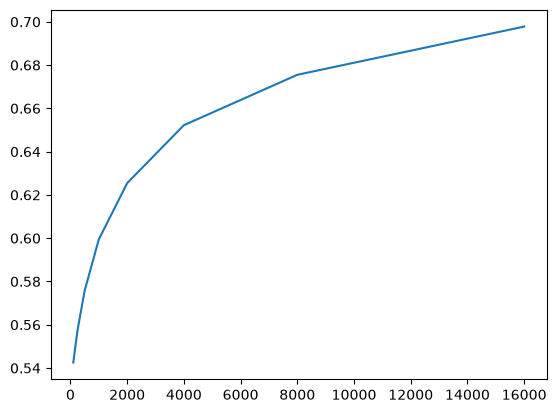

In [8]:
plt.plot((bar_size_comparison["events_per_bar"].astype('float64')), bar_size_comparison["free_power_delta"].astype('float64'))

plt.show()

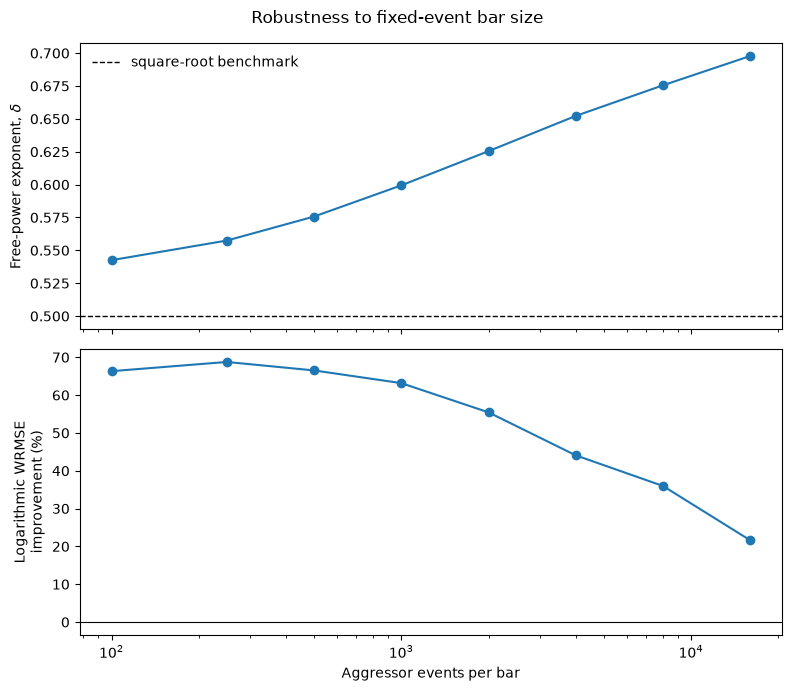

In [9]:
bar_size_comparison.to_csv(
    TABLE_DIR / "event_bar_size_robustness.csv",
    index=False,
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
)

axes[0].plot(
    bar_size_comparison["events_per_bar"],
    bar_size_comparison["free_power_delta"],
    marker="o",
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="square-root benchmark",
)

axes[0].set_ylabel(
    r"Free-power exponent, $\delta$"
)
axes[0].legend(frameon=False)

axes[1].plot(
    bar_size_comparison["events_per_bar"],
    bar_size_comparison[
        "log_wrmse_improvement_pct"
    ],
    marker="o",
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[1].set_xscale("log")
axes[1].set_xlabel("Aggressor events per bar")
axes[1].set_ylabel(
    "Logarithmic WRMSE\nimprovement (%)"
)

fig.suptitle(
    "Robustness to fixed-event bar size"
)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "07_event_bar_size_robustness.pdf",
    bbox_inches="tight",
)

plt.show()


In [10]:
# Common support: the overlap of the 1%-99% normalised-imbalance ranges of the bar
# sizes reported in Table tab:event-bar-robustness.
support_by_size = (
    pd.DataFrame(
        {
            events_per_bar: {
                "q01": analysis_n[
                    "normalised_imbalance"
                ].quantile(0.01),
                "q99": analysis_n[
                    "normalised_imbalance"
                ].quantile(0.99),
            }
            for events_per_bar, analysis_n
            in analyses_by_size.items()
            if events_per_bar in TABLE_EVENT_COUNTS
        }
    )
    .T
)

support_by_size

,q01,q99
250,6.927187e-07,0.000767
500,1.257617e-06,0.001210
1000,2.285702e-06,0.001919
2000,3.950383e-06,0.003011
4000,6.751872e-06,0.004695
8000,1.086381e-05,0.007256
16000,1.792915e-05,0.011114


In [11]:
common_lower_x = support_by_size["q01"].max()
common_upper_x = support_by_size["q99"].min()

common_lower_x, common_upper_x

(np.float64(1.792915311034146e-05), np.float64(0.0007673459641494836))

In [12]:
common_support_rows = []

for events_per_bar in TABLE_EVENT_COUNTS:
    analysis_n = analyses_by_size[events_per_bar]
    sample = analysis_n.loc[
        analysis_n["normalised_imbalance"].between(
            common_lower_x,
            common_upper_x,
        ),
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ],
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, _ = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    common_support_rows.append(
        {
            "events_per_bar": events_per_bar,
            "bars_used": len(sample),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
        }
    )

common_support_comparison = pd.DataFrame(
    common_support_rows
).sort_values("events_per_bar")

In [13]:
common_support_comparison.to_csv(TABLE_DIR / "event_bar_common_support_robustness.csv", index=False)
common_support_comparison


,events_per_bar,bars_used,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,250,7016716,0.537344,0.000115,0.000499,76.974890
1,500,3902943,0.587242,0.000075,0.000691,89.164155
2,1000,1996561,0.647293,0.000103,0.000784,86.880896
3,2000,938349,0.713123,0.000198,0.000759,73.937968
4,4000,399586,0.780262,0.000475,0.000838,43.326027
5,8000,155530,0.836346,0.000728,0.000808,9.969933
6,16000,56917,0.879433,0.002289,0.002303,0.604895


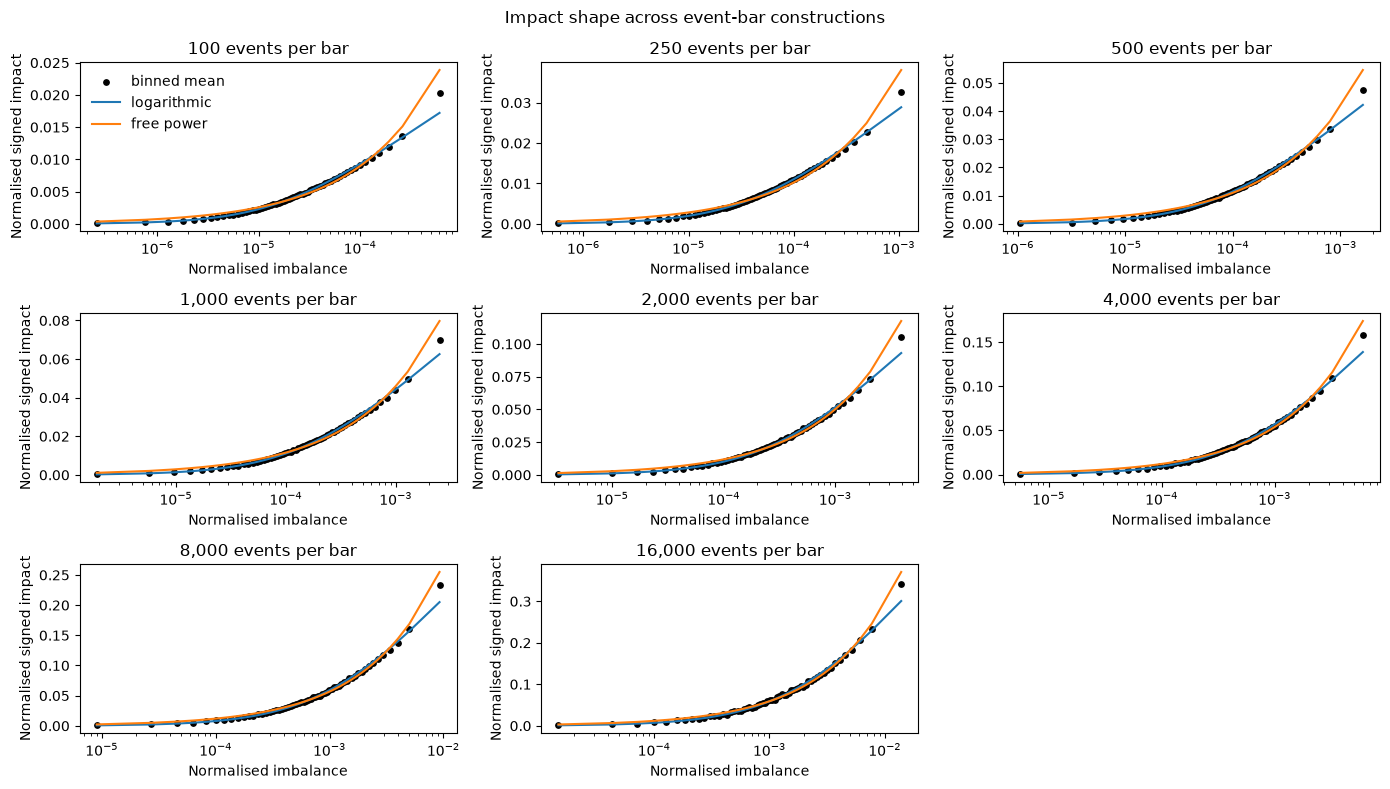

In [14]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(14, 8),
    sharex=False,
    sharey=False,
)

for ax, events_per_bar in zip(
    axes.ravel(),
    EVENT_COUNTS,
):
    analysis_n = analyses_by_size[events_per_bar]

    sample = analysis_n[
        [
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    ].dropna()

    curve = bin_impact_curve_with_uncertainty(
        sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison, predictions = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_BIN,
        x_scale=pooled_x_scale,
    )

    ax.scatter(
        curve["mean_x"],
        curve["mean_impact"],
        s=15,
        color="black",
        label="binned mean",
    )

    for model, colour in [
        ("logarithmic", "tab:blue"),
        ("free_power", "tab:orange"),
    ]:
        group = predictions.loc[
            predictions["model"] == model
        ].sort_values("x")

        ax.plot(
            group["x"],
            group["predicted_impact"],
            color=colour,
            label=model.replace("_", " "),
        )

    ax.set_xscale("log")
    ax.set_title(
        f"{events_per_bar:,} events per bar"
    )
    ax.set_xlabel("Normalised imbalance")
    ax.set_ylabel("Normalised signed impact")

axes.ravel()[-1].axis("off")
axes.ravel()[0].legend(frameon=False)

fig.suptitle(
    "Impact shape across event-bar constructions"
)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "08_event_bar_fitted_curves.pdf",
    bbox_inches="tight",
)

plt.show()

In [15]:
def bin_model_diagnostics(
    curve,
    predictions,
):
    observed = curve[
        [
            "bin_id",
            "mean_x",
            "mean_impact",
            "standard_error",
            "n_obs",
        ]
    ].copy()

    fitted = (
        predictions
        .pivot(
            index="x",
            columns="model",
            values="predicted_impact",
        )
        .reset_index()
        .rename(columns={"x": "mean_x"})
    )

    diagnostics = observed.merge(
        fitted,
        on="mean_x",
        how="inner",
    )

    diagnostics["weight"] = (
        1
        / diagnostics["standard_error"].pow(2)
    )

    diagnostics["log_weighted_squared_error"] = (
        diagnostics["weight"]
        * (
            diagnostics["mean_impact"]
            - diagnostics["logarithmic"]
        ).pow(2)
    )

    diagnostics["power_weighted_squared_error"] = (
        diagnostics["weight"]
        * (
            diagnostics["mean_impact"]
            - diagnostics["free_power"]
        ).pow(2)
    )

    diagnostics["log_minus_power_contribution"] = (
        diagnostics["log_weighted_squared_error"]
        - diagnostics["power_weighted_squared_error"]
    )

    return diagnostics.sort_values("mean_x")

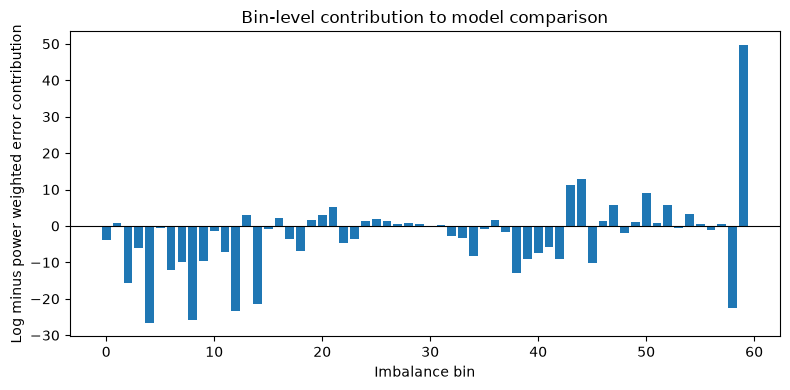

In [16]:
diagnostics = bin_model_diagnostics(
    curve,
    predictions,
)

plt.figure(figsize=(8, 4))

plt.bar(
    diagnostics["bin_id"],
    diagnostics["log_minus_power_contribution"],
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Imbalance bin")
plt.ylabel("Log minus power weighted error contribution")
plt.title("Bin-level contribution to model comparison")
plt.tight_layout()
plt.show()

In [17]:
tail_sensitivity_rows = []

ordered_curve = curve.sort_values(
    "mean_x"
).reset_index(drop=True)

for upper_bins_excluded in range(0, 5):
    if upper_bins_excluded == 0:
        fitted_curve = ordered_curve.copy()
    else:
        fitted_curve = ordered_curve.iloc[
            :-upper_bins_excluded
        ].copy()

    comparison, _ = compare_impact_models(
        fitted_curve,
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison.set_index("model")

    tail_sensitivity_rows.append(
        {
            "upper_bins_excluded": upper_bins_excluded,
            "bins_used": len(fitted_curve),
            "free_power_delta": fitted.loc[
                "free_power", "delta"
            ],
            "log_wrmse": fitted.loc[
                "logarithmic", "weighted_rmse"
            ],
            "power_wrmse": fitted.loc[
                "free_power", "weighted_rmse"
            ],
            "log_wrmse_improvement_pct": 100 * (
                fitted.loc[
                    "free_power", "weighted_rmse"
                ]
                - fitted.loc[
                    "logarithmic", "weighted_rmse"
                ]
            ) / fitted.loc[
                "free_power", "weighted_rmse"
            ],
        }
    )

tail_sensitivity = pd.DataFrame(
    tail_sensitivity_rows
)

tail_sensitivity.to_csv(TABLE_DIR / "event_bar_tail_sensitivity_16000.csv", index=False)
tail_sensitivity


,upper_bins_excluded,bins_used,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,0,60,0.697785,0.002814,0.003590,21.621223
1,1,59,0.709487,0.002003,0.003308,39.440074
2,2,58,0.720002,0.001874,0.003033,38.206047
3,3,57,0.725764,0.001700,0.002944,42.253452
4,4,56,0.732935,0.001677,0.002792,39.938724


In [18]:
# Bin-count sensitivity at the baseline (4,000) and largest (16,000) bar sizes.
bin_count_rows = []

for events_per_bar in BIN_SENSITIVITY_EVENT_SIZES:
    sample = analyses_by_size[events_per_bar][
        ["normalised_imbalance", "normalised_signed_impact"]
    ].dropna()

    for n_bins in [40, 60, 80, 100, 120, 240]:
        refined_curve = bin_impact_curve_with_uncertainty(
            sample,
            x_col="normalised_imbalance",
            impact_col="normalised_signed_impact",
            n_bins=n_bins,
            method="equal_count",
        )

        comparison, _ = compare_impact_models(
            refined_curve,
            min_obs_per_bin=100,
            x_scale=pooled_x_scale,
        )

        fitted = comparison.set_index("model")

        bin_count_rows.append(
            {
                "events_per_bar": events_per_bar,
                "n_bins": n_bins,
                "free_power_delta": fitted.loc[
                    "free_power", "delta"
                ],
                "log_wrmse": fitted.loc[
                    "logarithmic", "weighted_rmse"
                ],
                "power_wrmse": fitted.loc[
                    "free_power", "weighted_rmse"
                ],
                "log_wrmse_improvement_pct": 100 * (
                    fitted.loc[
                        "free_power", "weighted_rmse"
                    ]
                    - fitted.loc[
                        "logarithmic", "weighted_rmse"
                    ]
                ) / fitted.loc[
                    "free_power", "weighted_rmse"
                ],
            }
        )

bin_count_sensitivity = pd.DataFrame(bin_count_rows)
bin_count_sensitivity.to_csv(TABLE_DIR / "event_bar_bin_count_sensitivity.csv", index=False)
bin_count_sensitivity


,events_per_bar,n_bins,free_power_delta,log_wrmse,power_wrmse,log_wrmse_improvement_pct
0,4000,40,0.651932,0.001055,0.002102,49.811720
1,4000,60,0.652220,0.001163,0.002079,44.077102
2,4000,80,0.652472,0.001260,0.002091,39.729206
3,4000,100,0.652610,0.001320,0.002105,37.306752
4,4000,120,0.652578,0.001382,0.002118,34.770217
5,4000,240,0.652716,0.001553,0.002178,28.717809
6,16000,40,0.697748,0.002428,0.003456,29.736057
7,16000,60,0.697785,0.002814,0.003590,21.621223
8,16000,80,0.697628,0.003025,0.003669,17.546197
9,16000,100,0.697831,0.003158,0.003734,15.443623


In [19]:
curve.tail(5)[
    [
        "mean_x",
        "mean_impact",
        "median_impact",
        "impact_p25",
        "impact_p75",
        "n_obs",
    ]
]

,mean_x,mean_impact,median_impact,impact_p25,impact_p75,n_obs
55,0.004542,0.170723,0.170546,0.113073,0.231674,2433
56,0.005178,0.182137,0.182543,0.118416,0.246102,2433
57,0.006103,0.206405,0.204119,0.135550,0.272197,2433
58,0.007709,0.232763,0.227374,0.153455,0.307379,2433
59,0.013871,0.341983,0.316022,0.209857,0.429225,2434


In [20]:
TIME_WINDOWS = {
    "1min": 60,
    "150s": 150,
    "5min": 300,
    "10min": 600,
    "20min": 1_200,
}

In [21]:
# All windows from a single read of each monthly file.
time_bars_built = build_time_bars(FILES, list(TIME_WINDOWS))

time_bars_by_window = {}

for window, bars in time_bars_built.items():
    bars = bars.copy()

    bars["duration_seconds"] = TIME_WINDOWS[window]
    bars["end_time"] = (
        bars.index
        + pd.Timedelta(seconds=TIME_WINDOWS[window])
    )

    time_bars_by_window[window] = bars

    print(window, len(bars))

1min 2978649
150s 1191460
5min 595729
10min 297866
20min 148934


In [22]:
time_analyses = {}

for window, bars in time_bars_by_window.items():
    bars_for_analysis = bars.drop(
        columns=["high_low_range_bps"],
        errors="ignore",
    )

    analysis_t = attach_common_benchmark(
        bars_for_analysis,
        base_benchmark,
    )

    analysis_t = analysis_t.dropna(
        subset=[
            "normalised_imbalance",
            "normalised_signed_impact",
        ]
    )

    time_analyses[window] = analysis_t

In [23]:
time_rows = []
time_curves = {}
time_predictions = {}

for window, analysis_t in time_analyses.items():
    curve_t = bin_impact_curve_with_uncertainty(
        analysis_t,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=N_BINS,
        method="equal_count",
    )

    comparison_t, predictions_t = compare_impact_models(
        curve_t,
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison_t.set_index("model")

    time_rows.append({
        "window": window,
        "duration_seconds": TIME_WINDOWS[window],
        "bars_used": len(analysis_t),
        "median_trade_count": analysis_t["trade_count"].median(),
        "median_gross_volume_btc": analysis_t["gross_volume"].median(),
        "free_power_delta": fitted.loc["free_power", "delta"],
        "log_wrmse": fitted.loc["logarithmic", "weighted_rmse"],
        "power_wrmse": fitted.loc["free_power", "weighted_rmse"],
        "square_root_wrmse": fitted.loc[
            "square_root", "weighted_rmse"
        ],
        "log_wrmse_improvement_pct": (
            100
            * (
                fitted.loc["free_power", "weighted_rmse"]
                - fitted.loc["logarithmic", "weighted_rmse"]
            )
            / fitted.loc["free_power", "weighted_rmse"]
        ),
        "bins_used": fitted.loc["free_power", "bins_used"],
    })

    time_curves[window] = curve_t
    time_predictions[window] = predictions_t

time_bar_comparison = (
    pd.DataFrame(time_rows)
    .sort_values("duration_seconds")
    .reset_index(drop=True)
)

time_bar_comparison

,window,duration_seconds,bars_used,median_trade_count,median_gross_volume_btc,free_power_delta,log_wrmse,power_wrmse,square_root_wrmse,log_wrmse_improvement_pct,bins_used
0,1min,60,2977353,522.0,108.567,0.643759,0.000641,0.000713,0.002008,10.095773,60
1,150s,150,1190941,1328.0,291.064,0.684524,0.001016,0.000958,0.003752,-6.042439,60
2,5min,300,595469,2700.0,613.488,0.711938,0.001481,0.001157,0.005843,-28.038241,60
3,10min,600,297736,5500.0,1285.994,0.746403,0.001983,0.001562,0.009173,-26.956510,60
4,20min,1200,148869,11252.0,2691.476,0.782798,0.002554,0.002086,0.014416,-22.460786,60


In [24]:
# Export Table tab:time-bar-robustness: CSV with full precision, .tex tabular body.
# WRMSE in units of 10^-3 (as in Table tab:impact-model-comparison).
time_bar_comparison.to_csv(TABLE_DIR / "time_bar_robustness.csv", index=False)
WINDOW_LABELS = {"1min": "1 minute", "150s": "2.5 minutes", "5min": "5 minutes",
                 "10min": "10 minutes", "20min": "20 minutes"}
lines = [
    r"\begin{tabular}{lrrrrrr}",
    r"\toprule",
    r"Time bar & Bars used & Median events & Free-power $\delta$ & Log WRMSE & Power WRMSE & Log improvement \\",
    r" & & & & ($\times 10^{-3}$) & ($\times 10^{-3}$) & (\%) \\",
    r"\midrule",
]
for row in time_bar_comparison.itertuples():
    lines.append(" & ".join([
        WINDOW_LABELS[row.window], f"{row.bars_used:,}", f"{row.median_trade_count:,.0f}",
        f"{row.free_power_delta:.3f}", f"{1_000 * row.log_wrmse:.2f}", f"{1_000 * row.power_wrmse:.2f}",
        _signed(row.log_wrmse_improvement_pct, 1),
    ]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TABLE_DIR / "time_bar_robustness.tex").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

\begin{tabular}{lrrrrrr}
\toprule
Time bar & Bars used & Median events & Free-power $\delta$ & Log WRMSE & Power WRMSE & Log improvement \\
 & & & & ($\times 10^{-3}$) & ($\times 10^{-3}$) & (\%) \\
\midrule
1 minute & 2,977,353 & 522 & 0.644 & 0.64 & 0.71 & 10.1 \\
2.5 minutes & 1,190,941 & 1,328 & 0.685 & 1.02 & 0.96 & $-$6.0 \\
5 minutes & 595,469 & 2,700 & 0.712 & 1.48 & 1.16 & $-$28.0 \\
10 minutes & 297,736 & 5,500 & 0.746 & 1.98 & 1.56 & $-$27.0 \\
20 minutes & 148,869 & 11,252 & 0.783 & 2.55 & 2.09 & $-$22.5 \\
\bottomrule
\end{tabular}


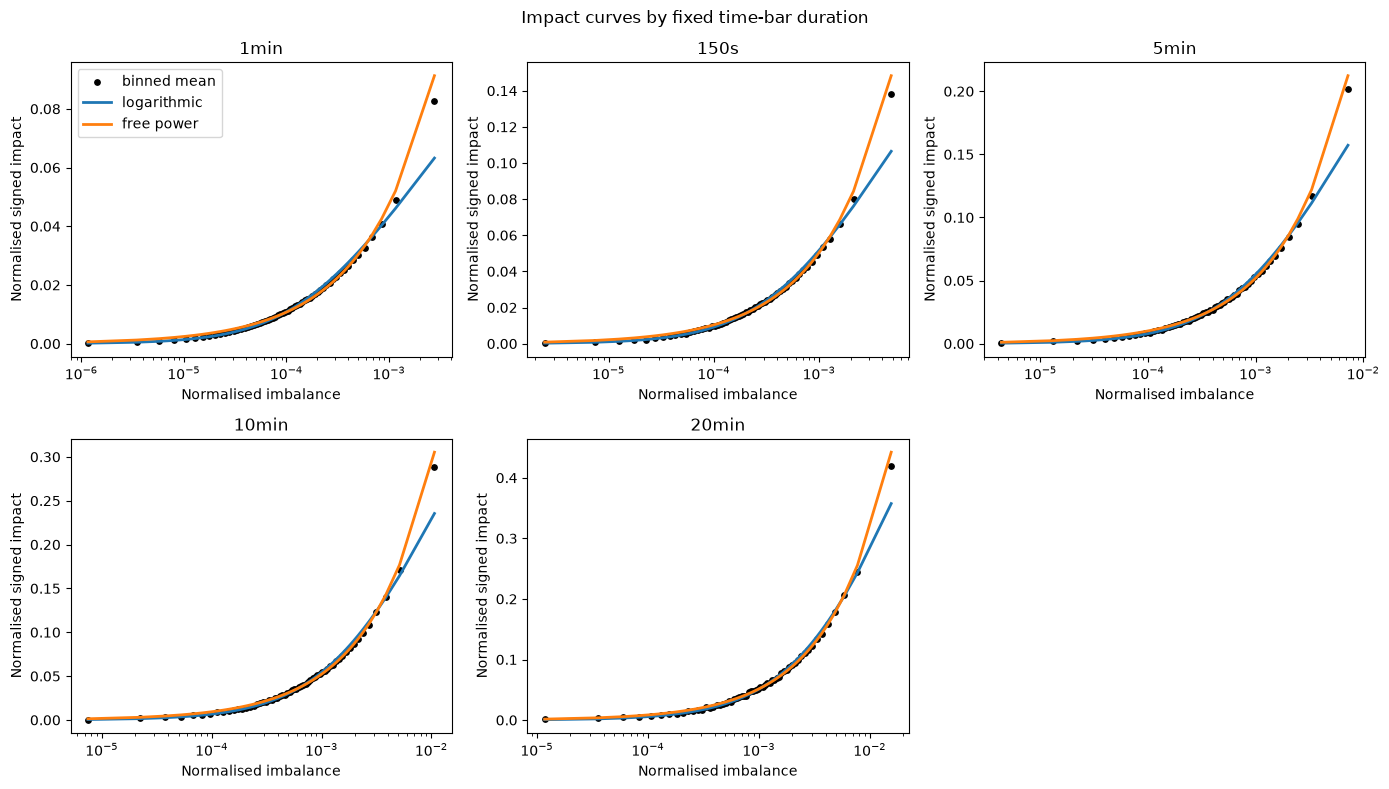

In [25]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharex=False,
    sharey=False,
)

axes = axes.ravel()

for ax, (window, _) in zip(
    axes,
    sorted(
        TIME_WINDOWS.items(),
        key=lambda item: item[1],
    ),
):
    curve_t = time_curves[window]
    predictions_t = time_predictions[window]

    ax.scatter(
        curve_t["mean_x"],
        curve_t["mean_impact"],
        s=15,
        color="black",
        label="binned mean",
    )

    for model, colour in [
        ("logarithmic", "tab:blue"),
        ("free_power", "tab:orange"),
    ]:
        group = predictions_t.loc[
            predictions_t["model"] == model
        ].sort_values("x")

        ax.plot(
            group["x"],
            group["predicted_impact"],
            color=colour,
            linewidth=2,
            label=model.replace("_", " "),
        )

    ax.set_xscale("log")
    ax.set_title(window)
    ax.set_xlabel("Normalised imbalance")
    ax.set_ylabel("Normalised signed impact")

axes[0].legend()

for ax in axes[len(TIME_WINDOWS):]:
    ax.set_visible(False)

fig.suptitle("Impact curves by fixed time-bar duration")
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "09_time_bar_fitted_curves.pdf",
    bbox_inches="tight",
)

plt.show()

In [26]:
time_fit_summary = []

for window, analysis_t in time_analyses.items():
    curve_t = time_curves[window]

    comparison_t, _ = compare_impact_models(
        curve_t.drop(columns="standard_error"),
        min_obs_per_bin=100,
        x_scale=pooled_x_scale,
    )

    fitted = comparison_t.set_index("model")

    time_fit_summary.append({
        "window": window,
        "delta": fitted.loc["free_power", "delta"],

        "log_rmse": fitted.loc["logarithmic", "rmse"],
        "power_rmse": fitted.loc["free_power", "rmse"],

        "log_wrmse": fitted.loc["logarithmic", "weighted_rmse"],
        "power_wrmse": fitted.loc["free_power", "weighted_rmse"],

        "unweighted_preference": (
            "log"
            if fitted.loc["logarithmic", "rmse"]
            < fitted.loc["free_power", "rmse"]
            else "power"
        ),

        "weighted_preference": (
            "log"
            if fitted.loc["logarithmic", "weighted_rmse"]
            < fitted.loc["free_power", "weighted_rmse"]
            else "power"
        ),
    })

pd.DataFrame(time_fit_summary)

,window,delta,log_rmse,power_rmse,log_wrmse,power_wrmse,unweighted_preference,weighted_preference
0,1min,0.608593,0.001591,0.000781,0.001591,0.000781,power,power
1,150s,0.656048,0.002434,0.001029,0.002434,0.001029,power,power
2,5min,0.690032,0.003303,0.001216,0.003303,0.001216,power,power
3,10min,0.723776,0.003984,0.001644,0.003984,0.001644,power,power
4,20min,0.759125,0.004765,0.002460,0.004765,0.002460,power,power
